# EURO-CORDEX downscaling

In [1]:
import torch
import pathlib
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy

import models
import datasets
import loss

LR data

In [6]:
PATH = '/rci_data/climate/CORDEX/'

cordex_dm = datasets.cordex.CORDEXDataModule(16, PATH, 16)
cordex_dm.setup(None)

Best model

In [10]:
CKPT_DIR = '/home/tomas/ctu/current/rci_home/SISR-downscaling/logs/lightning_logs/'
def load_checkpoint(version: int):
    dir = pathlib.Path(CKPT_DIR + f'version_{version}/checkpoints/')
    return [file for file in dir.iterdir() if file.is_file() and file.suffix == '.ckpt'][0]

torch.set_float32_matmul_precision("high")
ckpt = load_checkpoint(629)

model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model=models.EDSR(channels=1, scale_factor=16, features=128, residual_blocks=64, loss=loss.LossCombination([1], [
                                                         loss.L1Loss()])),
                                                     constraint=models.AddConstraintLayer(16)).cuda()
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'constraint' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['constraint'])`.


ConstrainedModel(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (test_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=test/
  )
  (model): EDSR(
    (train_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=train/
    )
    (val_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=val/
    )
    (test_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=test/
    )
    (loss): LossCombination(


Function to save tensor data as .nc file.

In [11]:
def save_data(data : torch.Tensor, dates : np.array, file_name : str):
    left, bottom, right, top = 4335000, 5555000, 4755000, 5955000

    easting  = np.linspace(left, right, 400)
    northing = np.linspace(top, bottom, 400)

    cordex_downscaled = xr.DataArray(
        data.detach().numpy(),
        dims=["time", "northing", "easting"],
        coords={
            "time": dates,
            "northing": northing,
            "easting":  easting,
        },
        name = 'tas'
    )
    cordex_downscaled = cordex_downscaled.rio.write_crs("EPSG:31468")
    cordex_downscaled = cordex_downscaled.rio.set_spatial_dims(x_dim="easting", y_dim="northing")
    cordex_downscaled.attrs['units'] = '°C'

    cordex_downscaled.to_netcdf(f"downscaled/{file_name}.nc")

Does the downscaling with the model on the loaded data

In [12]:
def do_downscaling(data_loader, file_prefix):
    downscaled = torch.zeros(0, 400, 400)
    dates = np.zeros(0, dtype='datetime64[s]')

    file_num = 1

    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            x = batch[0].cuda()

            downscaled_current = model(x).cpu().squeeze()

            downscaled = torch.cat((downscaled, downscaled_current), dim=0)

            dates = np.concat((dates, batch[1].squeeze().numpy().astype('datetime64[s]')))

            if (i + 1) % 50 == 0:
                save_data(downscaled, dates, f'{file_prefix}_{file_num}')
                file_num += 1
                downscaled = torch.zeros(0, 400, 400)
                dates = np.zeros(0, dtype='datetime64[s]')

    save_data(downscaled, dates, f'{file_prefix}_{file_num}')

In [13]:
do_downscaling(cordex_dm.train_dataloader(), 'train')
do_downscaling(cordex_dm.val_dataloader(), 'val')
do_downscaling(cordex_dm.test_dataloader(), 'test')

Examples

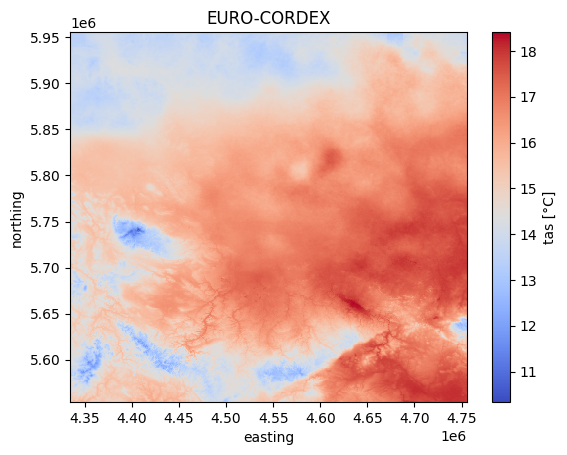

In [2]:
cordex = xr.open_mfdataset('downscaled/*.nc', decode_coords="all")
cordex = cordex["tas"]

DATE = '2003-5-1'

cordex = cordex.sel(time=DATE)

fig, ax = plt.subplots(ncols=1)
cordex.plot(ax = ax, cmap="coolwarm")
ax.set_title('EURO-CORDEX')
plt.show()

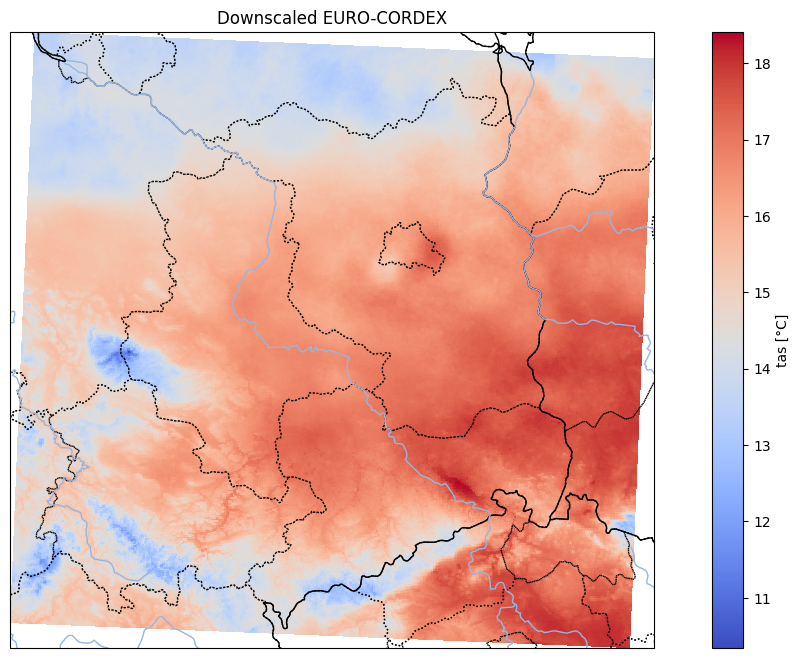

In [15]:
fig, ax = plt.subplots(ncols=1, subplot_kw=dict(projection=cartopy.crs.UTM(33)), figsize = (15, 8))

im = cordex.plot(
    ax=ax,
    transform=cartopy.crs.epsg(31468),
    cmap="coolwarm",
    add_colorbar=True
)

ax.set_title('Downscaled EURO-CORDEX')

ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.BORDERS)
ax.add_feature(cartopy.feature.STATES, linestyle=":")

ax.add_feature(cartopy.feature.COASTLINE)
plt.show()